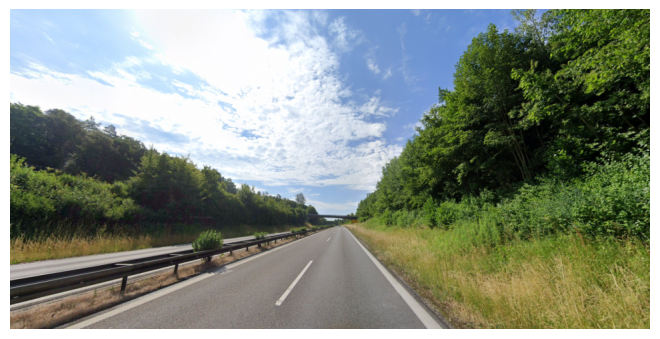

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import time

start = time.time()


#img = ski.io.imread("img/img4.jpg")
img = ski.io.imread("img/img1.png")

def resize_preserve_aspect(image, target_height=720):
    h, w = image.shape[:2]
    aspect_ratio = w / h
    target_width = int(target_height * aspect_ratio)
    resized = ski.transform.resize(image, (target_height, target_width), anti_aliasing=True)
    return resized

img = resize_preserve_aspect(img, target_height=480)

plt.imshow(img)
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


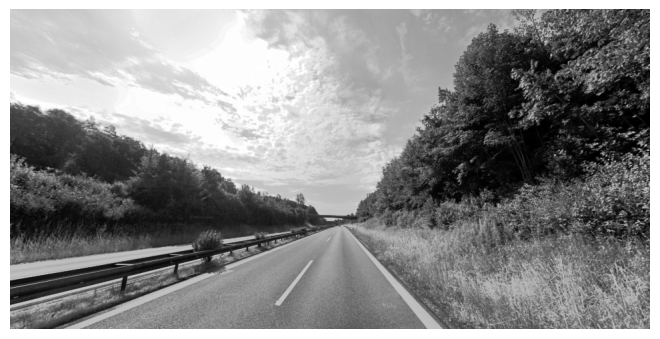

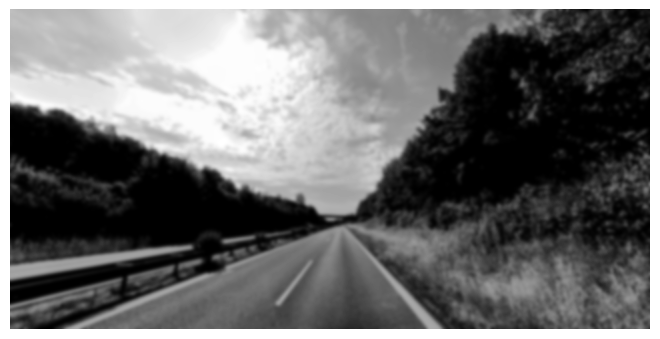

In [2]:

#convert to grayscale
img_rgb = img[..., :3]
gray_image = ski.color.rgb2gray(img_rgb)

equalized = ski.exposure.equalize_hist(gray_image)

gray_image = equalized
# plot grayscale image
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

gray_image = ski.exposure.rescale_intensity(gray_image, in_range=(0.25, 1.0), out_range=(0, 1))
#gray_clahe = ski.exposure.equalize_adapthist(gray_image, clip_limit=0.03)

#blurred = gray_image
blurred = ski.filters.gaussian(gray_image, sigma=2.5)
# plot blurred image
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

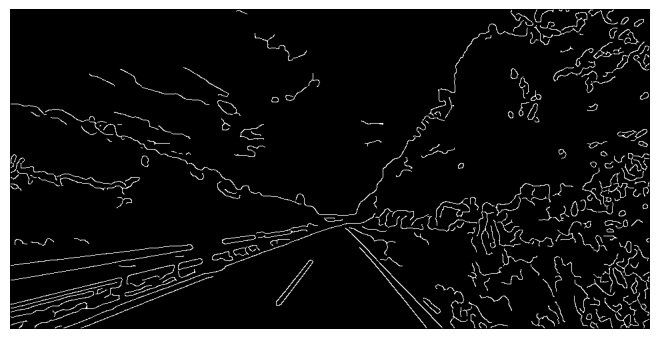

In [3]:

edges = ski.feature.canny(blurred, sigma=1, low_threshold=0.1, high_threshold=0.2)
# plot edges
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()


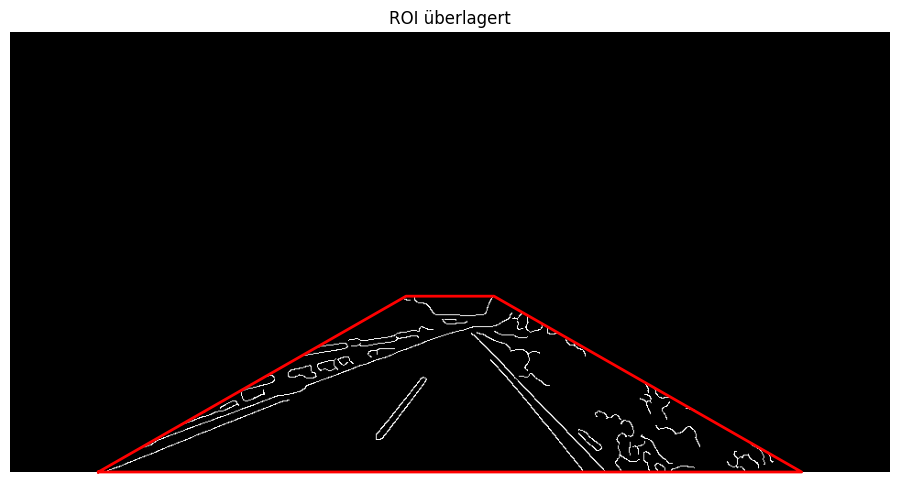

In [4]:
h, w = edges.shape
trapezoid = np.array([
    (int(w * 0.1), int(h)),          # unten links
    (int(w * 0.45), int(h * 0.6)),   # oben links
    (int(w * 0.55), int(h * 0.6)),   # oben rechts
    (int(w * 0.9), int(h)),          # unten rechts
], dtype=np.int32)

def apply_roi_mask_to_edges(edges, trapezoid_vertices):
    mask = np.zeros_like(edges, dtype=bool)
    
    # separate x/y-Koordinaten und sicherstellen, dass sie inbounds sind
    r = np.clip([v[1] for v in trapezoid_vertices], 0, edges.shape[0]-1)
    c = np.clip([v[0] for v in trapezoid_vertices], 0, edges.shape[1]-1)

    rr, cc = ski.draw.polygon(r, c)
    mask[rr, cc] = True
    return edges & mask

edges_roi = apply_roi_mask_to_edges(edges, trapezoid)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(edges_roi, cmap='gray')

# Trapez als Linie zeichnen (geschlossener Pfad)
trapezoid_closed = np.vstack([trapezoid, trapezoid[0]])  # zurück zum Startpunkt
ax.plot(trapezoid_closed[:, 0], trapezoid_closed[:, 1], color='red', linewidth=2)

ax.set_title("ROI überlagert")
plt.axis('off')
plt.show()

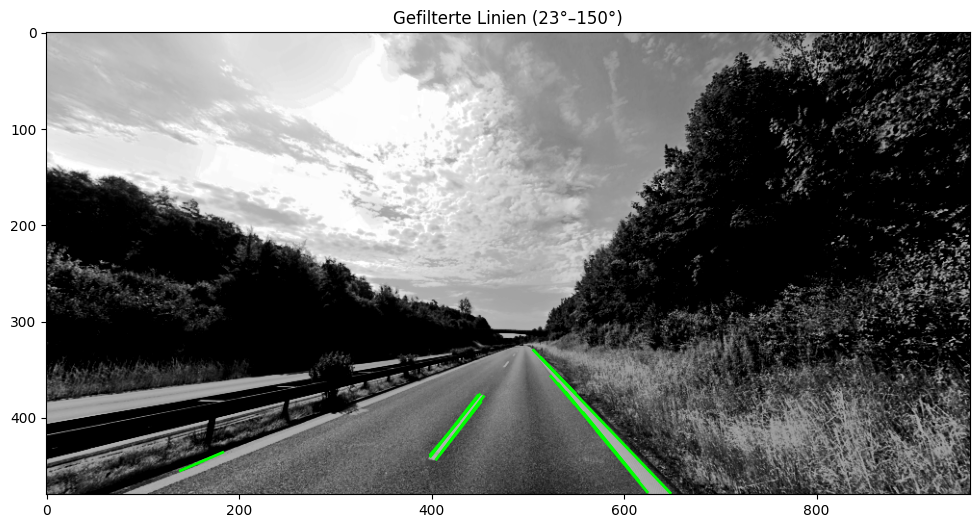

In [5]:

# Probabilistic Hough Transform
lines = ski.transform.probabilistic_hough_line(edges_roi, threshold=10, line_length=25, line_gap=5)

# Einstellbarer Winkelbereich (z. B. nur Linien zwischen ±30–60°)
angle_min = 23   # untere Winkelgrenze (°)
angle_max = 150   # obere Winkelgrenze (°)

filtered_lines = []
for p0, p1 in lines:
    dx = p1[0] - p0[0]
    dy = p1[1] - p0[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # beide Seiten zulassen
    if angle_min < abs(angle) < angle_max:
        filtered_lines.append((p0, p1))

# Anzeige
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(gray_image, cmap='gray')
for p0, p1 in filtered_lines:
    ax.plot((p0[0], p1[0]), (p0[1], p1[1]), color='lime', linewidth=2)

plt.title(f"Gefilterte Linien ({angle_min}°–{angle_max}°)")
plt.show()


In [6]:

def average_direction(p0, p1):
    dx = p1[0] - p0[0]
    dy = p1[1] - p0[1]
    return np.degrees(np.arctan2(dy, dx))

def line_midpoint(p0, p1):
    return ((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2)

def group_similar_lines(lines, angle_thresh=5, x_thresh=10):
    groups = []
    for line in lines:
        p0, p1 = line
        angle = average_direction(p0, p1)
        midpoint = line_midpoint(p0, p1)

        matched = False
        for group in groups:
            ga, gm = group['angle'], group['midpoint']
            if abs(angle - ga) < angle_thresh and abs(midpoint[0] - gm[0]) < x_thresh:
                group['lines'].append(line)
                group['angle'] = (group['angle'] + angle) / 2
                group['midpoint'] = ((group['midpoint'][0] + midpoint[0]) / 2,
                                     (group['midpoint'][1] + midpoint[1]) / 2)
                matched = True
                break

        if not matched:
            groups.append({'angle': angle, 'midpoint': midpoint, 'lines': [line]})
    return groups

def fit_line_through_group(group_lines):
    points = []
    for p0, p1 in group_lines:
        points.extend([p0, p1])
    points = np.array(points)

    # Fit Linie y = mx + b
    xs, ys = points[:, 0], points[:, 1]
    if len(xs) < 2:
        return None  # zu wenig Punkte
    poly = np.polyfit(xs, ys, deg=1)
    return poly


def compute_intersection(poly1, poly2):
    m1, b1 = poly1
    m2, b2 = poly2
    if m1 == m2:
        return None  # Parallel
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return (x, y)



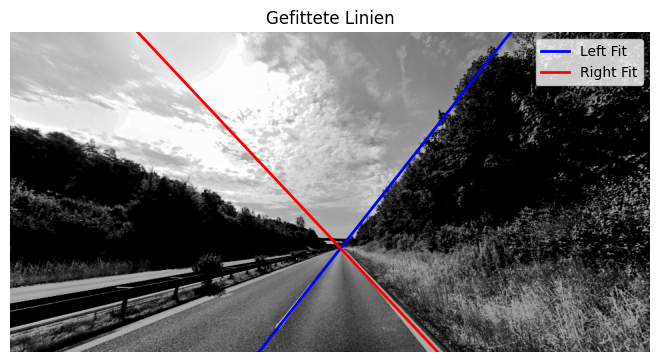

In [7]:

image_center_x = gray_image.shape[1] // 2
left_lines = []
right_lines = []

for p0, p1 in filtered_lines:
    x_avg = (p0[0] + p1[0]) / 2
    if x_avg < image_center_x:
        left_lines.append((p0, p1))
    else:
        right_lines.append((p0, p1))

left_group = group_similar_lines(left_lines)
right_group = group_similar_lines(right_lines)

# Wähle jeweils die größte Gruppe (meiste Linien)
best_left = max(left_group, key=lambda g: len(g['lines']), default=None)
best_right = max(right_group, key=lambda g: len(g['lines']), default=None)

# Line fitten
left_fit = fit_line_through_group(best_left['lines']) if best_left else None
right_fit = fit_line_through_group(best_right['lines']) if best_right else None

# plot left fit and right fit
if left_fit is not None:
    x_left = np.array([0, gray_image.shape[1]])
    y_left = left_fit[0] * x_left + left_fit[1]
    plt.plot(x_left, y_left, color='blue', linewidth=2, label='Left Fit')
if right_fit is not None:
    x_right = np.array([0, gray_image.shape[1]])
    y_right = right_fit[0] * x_right + right_fit[1]
    plt.plot(x_right, y_right, color='red', linewidth=2, label='Right Fit')
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.title('Gefittete Linien')
plt.legend()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()



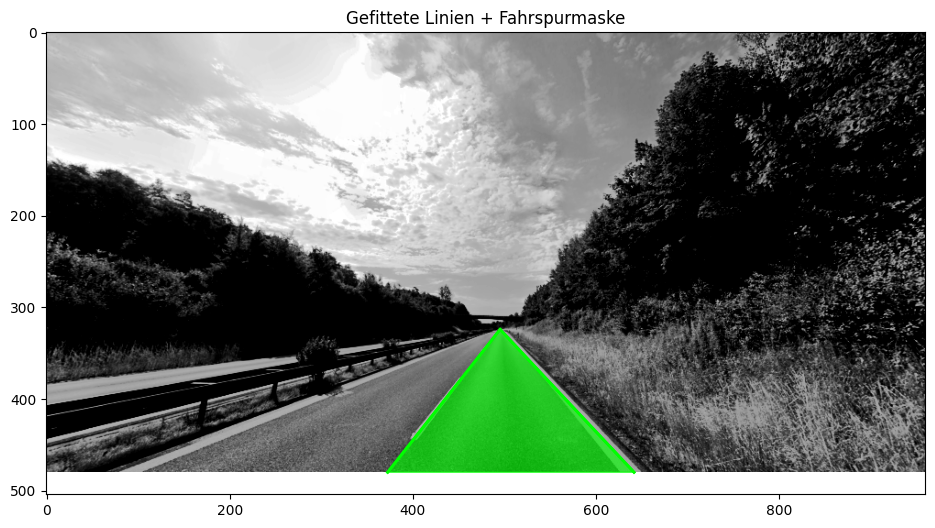

In [8]:
def extrapolate_line(poly, y1, y2):
    # y = mx + b => x = (y - b) / m
    m, b = poly
    x1 = (y1 - b) / m
    x2 = (y2 - b) / m
    return (x1, y1), (x2, y2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(gray_image, cmap='gray')

height = gray_image.shape[0]

if left_fit is not None and right_fit is not None:
    bottom_y = height
    top_y_default = int(height * 0.6)

    intersection = compute_intersection(left_fit, right_fit)
    if intersection and intersection[1] > top_y_default:
        top_y = intersection[1]
    else:
        top_y = top_y_default

    l0, l1 = extrapolate_line(left_fit, bottom_y, top_y)
    r0, r1 = extrapolate_line(right_fit, bottom_y, top_y)

    polygon = Polygon([l0, l1, r1, r0], closed=True, color='lime', alpha=0.4)
    ax.add_patch(polygon)

    ax.plot([l0[0], l1[0]], [l0[1], l1[1]], 'lime', linewidth=2)
    ax.plot([r0[0], r1[0]], [r0[1], r1[1]], 'lime', linewidth=2)

    polygon = Polygon([l0, l1, r1, r0], closed=True, color='lime', alpha=0.4)
    ax.add_patch(polygon)

    ax.plot([l0[0], l1[0]], [l0[1], l1[1]], 'lime', linewidth=2)
    ax.plot([r0[0], r1[0]], [r0[1], r1[1]], 'lime', linewidth=2)

plt.title("Gefittete Linien + Fahrspurmaske")
plt.show()

In [9]:
end = time.time()
print(f"Total execution time: {end - start:.2f} seconds")

Total execution time: 2.34 seconds
